In [ ]:
import scanpy as sc
import numpy as npp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
import gffutils

### Process gene expression data (GUIDE CAPTURE)

In [2]:
gex = sc.read_h5ad("GEX2.h5ad")

# set the gene expression count matrix to be the sum of all three types of reads
gex.X = gex.layers["ambiguous"]+gex.layers["mature"]+gex.layers["nascent"]

In [3]:
# count the number of gene expression UMIs per cell
counts = gex.X.sum(axis=1)
counts = np.asarray(counts).flatten()
gex.obs["GEX_UMIS"] = counts

In [4]:
def plot_knee(umi_counts, ncells):
    # sort UMI counts in descending order
    sorted_counts = np.sort(umi_counts)[::-1]

    plt.figure(figsize=(5,5))
    plt.plot(list(range(len(sorted_counts))), sorted_counts, linewidth=4, color="black")

    plt.xlabel("Barcode rank")
    plt.ylabel("UMI counts")

    plt.yscale("log")
    plt.xscale("log")

    plt.axvline(ncells, linewidth=2, linestyle='--', color="red")
    
    print(f"UMIs at {ncells}th cell: {sorted_counts[ncells]}")

UMIs at 6000th cell: 1151.0000396


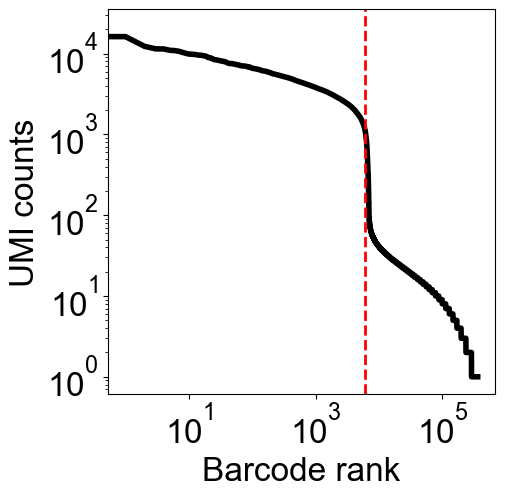

In [5]:
plt.rcParams["font.size"] = 24
plt.rcParams["font.family"] = "Arial"
plt.rcParams["figure.figsize"] = (5,5)

plot_knee(gex.obs["GEX_UMIS"], ncells=6000)
plt.savefig("DC_GEX_knee.png", dpi=300, bbox_inches="tight")

In [6]:
# only keep cells with >threshold UMIs
gex = gex[gex.obs["GEX_UMIS"]>1150]

In [7]:
gex.obs["GEX_UMIS"].mean(), gex.obs["GEX_UMIS"].median()

(2778.3694621729237, 2474.9992466999997)

### Process guide data (GUIDE CAPTURE)

In [8]:
guide = sc.read_h5ad("GUIDE1.h5ad")
guide = guide.to_df()

In [9]:
# merge the gene expression and guide objects
gex.obs = gex.obs.merge(guide, left_index=True, right_index=True, how="left")
# if a guide is not detected in a cell, set its count to 0
gex.obs = gex.obs.fillna(0)
# count the number of guide UMIs per cell
gex.obs["GUIDE_UMIS"] = gex.obs[guide.columns].sum(axis=1)

In [10]:
# mixing plot - want points NOT to lie along the x or y axes
#sns.scatterplot(x=gex.obs["GEX_UMIS"], y=gex.obs["GUIDE_UMIS"], alpha=0.1)

### Process gene expression data (CROP)

In [11]:
gex_crop = sc.read_h5ad("CROP_GEX1.h5ad")
gex_crop.X = gex_crop.layers["ambiguous"]+gex_crop.layers["mature"]+gex_crop.layers["nascent"]

In [12]:
counts = gex_crop.X.sum(axis=1)
counts = np.asarray(counts).flatten()
gex_crop.obs["GEX_UMIS"] = counts

UMIs at 6200th cell: 1179.000992


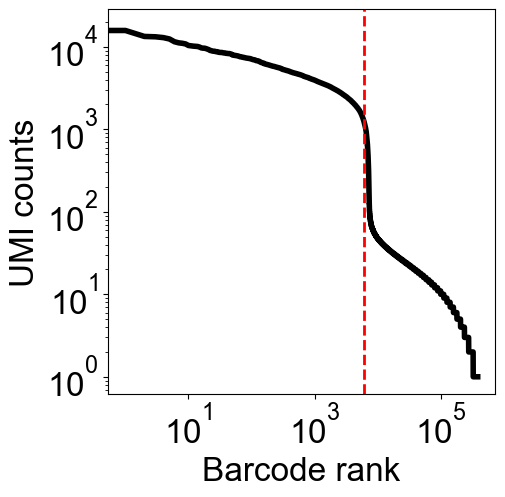

In [13]:
plot_knee(gex_crop.obs["GEX_UMIS"], ncells=6200)
plt.savefig("CROP_GEX_knee.png", dpi=300, bbox_inches="tight")

In [14]:
gex_crop = gex_crop[gex_crop.obs["GEX_UMIS"]>1180]

In [15]:
gex_crop.obs["GEX_UMIS"].mean(), gex_crop.obs["GEX_UMIS"].median()

(2844.388430896565, 2521.00037725)

### Process guide data (CROP)

In [16]:
guide_crop = sc.read_h5ad("CROP_GUIDE1.h5ad")
guide_crop = guide_crop.to_df()

In [17]:
gex_crop.obs = gex_crop.obs.merge(guide_crop, left_index=True, right_index=True, how="left")
gex_crop.obs = gex_crop.obs.fillna(0)
gex_crop.obs["GUIDE_UMIS"] = gex_crop.obs[guide_crop.columns].sum(axis=1)

In [18]:
#sns.scatterplot(x=gex_crop.obs["GEX_UMIS"], y=gex_crop.obs["GUIDE_UMIS"])

### Histogram of number of gene expression UMIs for both libraries

In [19]:
counts = pd.DataFrame({"Direct capture": gex.obs["GEX_UMIS"],
                       "CROP-seq": gex_crop.obs["GEX_UMIS"]})
# convert the table from a wide to a long table
counts = counts.melt().dropna()
counts.columns = ["Method", "# GEX UMIs"]

/var/folders/hz/kz7qqv9d2_d4sjp7b0zyz0y00000gq/T/ipykernel_66347/1119034430.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="# GEX UMIs", y="Method",


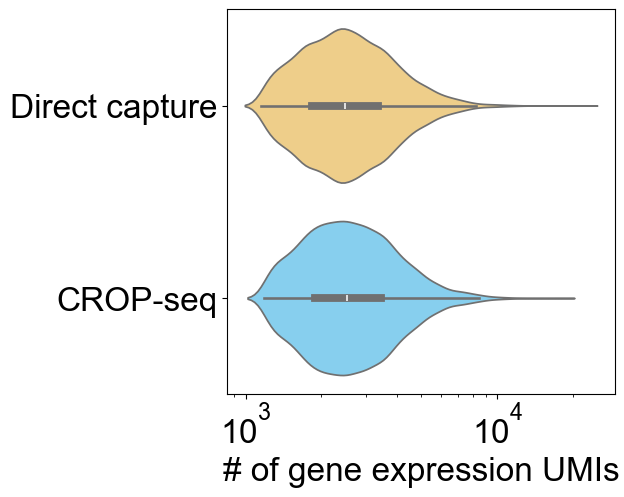

In [20]:
sns.violinplot(x="# GEX UMIs", y="Method", 
               data=counts, log_scale=True,
               palette=["#ffd479","#76d6ff"])
plt.xlabel("# of gene expression UMIs")
plt.ylabel("")
plt.savefig("GEX_UMIS.png", dpi=300, bbox_inches="tight")

### Histogram of number of guide UMIs per guide for both libraries

In [21]:
guide_counts = pd.DataFrame({"Direct capture": gex.obs["GUIDE_UMIS"],
                             "CROP-seq": gex_crop.obs["GUIDE_UMIS"]})
guide_counts = guide_counts.melt().dropna()
guide_counts.columns = ["Method", "# GUIDE UMIs"]

/var/folders/hz/kz7qqv9d2_d4sjp7b0zyz0y00000gq/T/ipykernel_66347/1850530268.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="# GUIDE UMIs", y="Method",


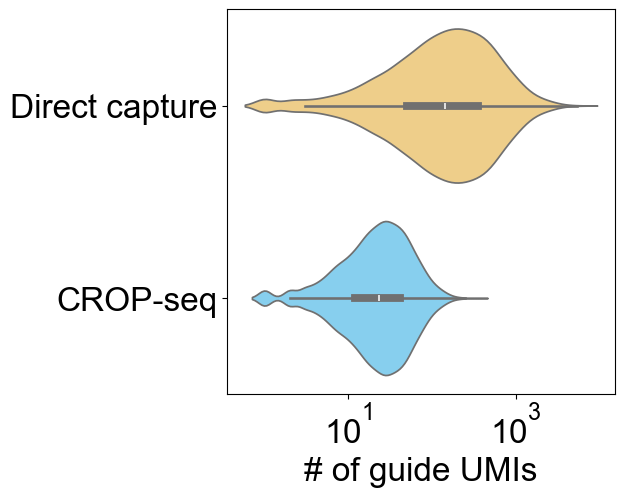

In [22]:
sns.violinplot(x="# GUIDE UMIs", y="Method", 
               data=guide_counts[guide_counts["# GUIDE UMIs"]>0], 
               log_scale=True, palette=["#ffd479","#76d6ff"])
plt.xlabel("# of guide UMIs")
plt.ylabel("")
plt.savefig("GUIDE_UMIS.png", dpi=300, bbox_inches="tight")

In [23]:
# calculate fraction of cells with nonzero 
guide_frac_nonzero = np.mean(gex.obs["GUIDE_UMIS"]>0)
crop_guide_frac_nonzero = np.mean(gex_crop.obs["GUIDE_UMIS"]>0)

<Axes: >

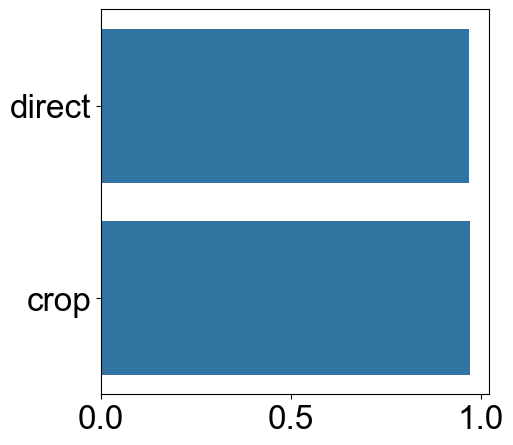

In [25]:
sns.barplot(y=["direct", "crop"],
            x=[guide_frac_nonzero, crop_guide_frac_nonzero])
# TODO: place a number on the barplot

In [36]:
((gex.obs.iloc[:,1:]>=5).sum(axis=1)>0).mean()

0.9308448591901349

In [37]:
((gex_crop.obs.iloc[:,1:]>=5).sum(axis=1)>0).mean()

0.897258064516129

### Distributions of counts for individual guides (GUIDE)

In [26]:
guides = guide.columns.tolist()

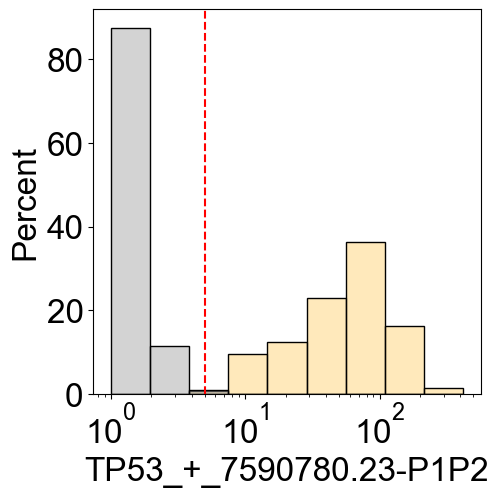

In [27]:
cutoff = 5

for g in ["TP53_+_7590780.23-P1P2"]:
    gcounts = gex.obs[g]
    gcounts = gcounts[gcounts>0]

    gcounts = pd.DataFrame(gcounts)
    gcounts["real"] = False
    gcounts.loc[gcounts[g]>cutoff,"real"] = True

    if gcounts["real"].sum()<100:
        continue
    
    sns.histplot(x=g, hue="real", data=gcounts, log_scale=True, 
                common_norm=False, stat="percent", alpha=0.5,
                palette=["#a9a9a9","#ffd479"])
    
    plt.axvline(cutoff, linestyle='--', color="red")
    plt.legend("", frameon=False)
    plt.savefig("DC_example_guide.png", dpi=300, bbox_inches="tight")
    plt.show()

### Distributions of counts for individual guides (CROP)

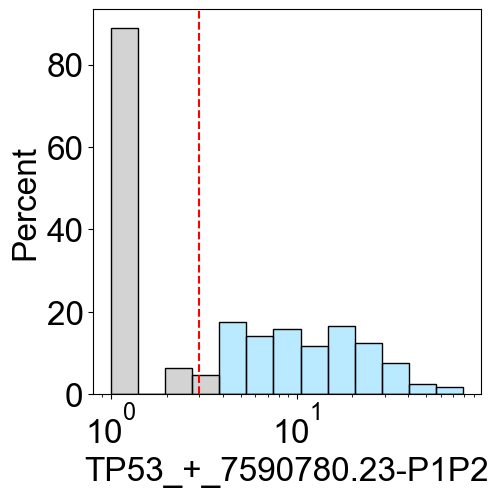

In [75]:
cutoff = 3

for g in ["TP53_+_7590780.23-P1P2"]:
    gcounts = gex_crop.obs[g]
    gcounts = gcounts[gcounts>0]

    gcounts = pd.DataFrame(gcounts)
    gcounts["real"] = False
    gcounts.loc[gcounts[g]>cutoff,"real"] = True

    if gcounts["real"].sum()<100:
        continue
    
    sns.histplot(x=g, hue="real", data=gcounts, log_scale=True, 
                 common_norm=False, stat="percent", alpha=0.5,
                 palette=["#a9a9a9","#76d6ff"])
    
    plt.axvline(cutoff, linestyle='--', color="red")
    plt.legend("", frameon=False)
    plt.savefig("CROP_example_guide.png",  dpi=300, bbox_inches="tight")
    plt.show()

### Make saturation curves for guide libraries

In [76]:
results = []

for counts in [1000000,3000000,10000000,30000000]:
    adata = sc.read_h5ad(f"GUIDE_S1.{counts}_kb_kite/counts_unfiltered_modified/adata.h5ad")
    cells = list(set(gex.obs.index) & set(adata.obs.index))
    adata = adata[cells]
    med_umis = np.median(np.asarray(adata.X.sum(axis=1)).flatten())
    nreads = counts/len(cells)
    results.append([nreads,med_umis,"Direct capture"])

for counts in [1000000,3000000,10000000,30000000]:
    adata = sc.read_h5ad(f"CROP_GUIDE1_S4.{counts}_kb_kite/counts_unfiltered_modified/adata.h5ad")
    cells = list(set(gex_crop.obs.index) & set(adata.obs.index))
    adata = adata[cells]
    med_umis = np.median(np.asarray(adata.X.sum(axis=1)).flatten())
    nreads = counts/len(cells)
    results.append([nreads,med_umis,"CROP-seq"])

In [77]:
results = pd.DataFrame(results)
results.columns = ["Reads per cell","UMIs per cell","Method"]

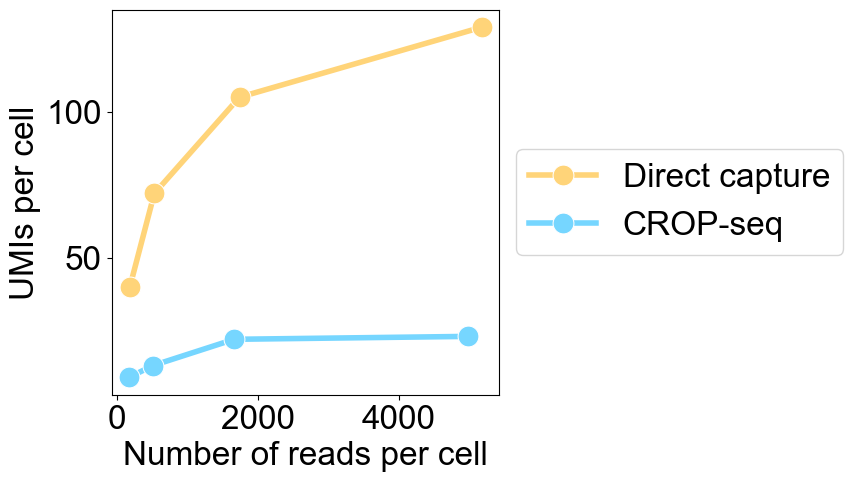

In [78]:
sns.lineplot(x="Reads per cell", y="UMIs per cell", hue="Method", data=results,
             palette=["#ffd479","#76d6ff"], linewidth=4, marker='o', markersize=15)
plt.xlabel("Number of reads per cell")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig("guide_saturation_curve.png",  dpi=300, bbox_inches="tight")

### Make UMAP (guide)

In [79]:
db = gffutils.FeatureDB("/Users/tkzeng/Dropbox/engreitz/statin_pilot/gencode.v46.annotation.db")

id_to_name = {}

for gene in db.features_of_type("gene"):
    gene_id = gene["gene_id"][0]
    gene_name = gene["gene_name"][0]
    id_to_name[gene_id] = gene_name

In [80]:
gex.var.index = gex.var.index.map(id_to_name)
gex.var_names_make_unique()

gex.var["mt"] = gex.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    gex, qc_vars=["mt"], inplace=True, log1p=True
)

# sc.pl.violin(
#     gex,
#     ["GEX_UMIS", "pct_counts_mt"],
#     jitter=0.4,
#     multi_panel=True,
# )

sc.pp.filter_cells(gex, min_genes=100)
sc.pp.filter_genes(gex, min_cells=3)

# Saving count data
gex.layers["counts"] = gex.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(gex)
# Logarithmize the data
sc.pp.log1p(gex)

sc.pp.highly_variable_genes(gex, n_top_genes=2000)

sc.tl.pca(gex)
sc.pp.neighbors(gex)
sc.tl.umap(gex)

/Users/tkzeng/miniconda3/envs/scvi-dev/lib/python3.11/site-packages/anndata/utils.py:260: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  warnings.warn(


In [81]:
# sc.pl.umap(gex)

### Calculate knockdown (guide)

In [82]:
gex_copy = gex.copy()
    
guide_counts = gex_copy.obs[guides]
guide_assign = guide_counts[guide_counts>=5]
genes = [x.split('_')[0] for x in guides]
guide_assign.columns = genes

gene_assign = {}
for gene in set(genes):
    gene_assign[gene] = guide_assign[gene].sum(axis=1)>0
gene_assign = pd.DataFrame(gene_assign)
gex_copy.obs = gene_assign

In [83]:
all_de = []
for gene in set(genes):
    gex_copy.obs["targeted"] = gex_copy.obs[gene].astype(str)
    sc.tl.rank_genes_groups(gex_copy, groupby="targeted", method="t-test_overestim_var")
    de = sc.get.rank_genes_groups_df(gex_copy, group="True")
    de = de[de["names"]==gene]
    de["ncells"] = np.sum(gex_copy.obs["targeted"]=="True")
    all_de.append(de)
all_de = pd.concat(all_de)

In [84]:
#sns.histplot(all_de["logfoldchanges"][all_de["logfoldchanges"]>-15])

### Make UMAP (crop)

In [85]:
gex_crop.var.index = gex_crop.var.index.map(id_to_name)
gex_crop.var_names_make_unique()

gex_crop.var["mt"] = gex_crop.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    gex_crop, qc_vars=["mt"], inplace=True, log1p=True
)

# sc.pl.violin(
#     gex_crop,
#     ["GEX_UMIS", "pct_counts_mt"],
#     jitter=0.4,
#     multi_panel=True,
# )

sc.pp.filter_cells(gex_crop, min_genes=100)
sc.pp.filter_genes(gex_crop, min_cells=3)

# Saving count data
gex_crop.layers["counts"] = gex_crop.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(gex_crop)
# Logarithmize the data
sc.pp.log1p(gex_crop)

sc.pp.highly_variable_genes(gex_crop, n_top_genes=2000)

sc.tl.pca(gex_crop)
sc.pp.neighbors(gex_crop)
sc.tl.umap(gex_crop)

/Users/tkzeng/miniconda3/envs/scvi-dev/lib/python3.11/site-packages/anndata/utils.py:260: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  warnings.warn(


### Calculate knockdown (crop)

In [86]:
gex_crop_copy = gex_crop.copy()

guide_counts = gex_crop_copy.obs[guides]
guide_assign = guide_counts[guide_counts>=3]
genes = [x.split('_')[0] for x in guides]
guide_assign.columns = genes

gene_assign = {}
for gene in set(genes):
    gene_assign[gene] = guide_assign[gene].sum(axis=1)>0
gene_assign = pd.DataFrame(gene_assign)
gex_crop_copy.obs = gene_assign

In [87]:
all_de_crop = []
for gene in set(genes):
    gex_crop_copy.obs["targeted"] = gex_crop_copy.obs[gene].astype(str)
    sc.tl.rank_genes_groups(gex_crop_copy, groupby="targeted", method="t-test_overestim_var")
    de = sc.get.rank_genes_groups_df(gex_crop_copy, group="True")
    de = de[de["names"]==gene]
    de["ncells"] = np.sum(gex_crop_copy.obs["targeted"]=="True")
    all_de_crop.append(de)
all_de_crop = pd.concat(all_de_crop)

In [88]:
all_de["method"] = "Direct capture"
all_de_crop["method"] = "CROP-seq"
de_direct_crop = pd.concat([all_de,all_de_crop])

In [89]:
de_direct_crop = de_direct_crop[de_direct_crop["names"]!="JUNB"]
de_direct_crop.loc[de_direct_crop["logfoldchanges"]>0,["pvals","pvals_adj"]] = 1

In [142]:
de_direct_crop[de_direct_crop["method"]=="Direct capture"].sort_values(by="pvals")

,names,scores,logfoldchanges,pvals,pvals_adj,ncells,method
33251,ITGB1,-9.630595,-3.220815,7.614428e-17,2.531949e-12,86,Direct capture
33251,CALCRL,-7.412618,-3.049972,9.303146e-11,3.093482e-06,48,Direct capture
33251,ITGA5,-7.007570,-3.693263,2.681223e-09,8.915602e-05,44,Direct capture
33251,FLI1,-6.254595,-2.725232,1.749041e-08,5.815910e-04,52,Direct capture
33251,PTK2,-6.178030,-2.438203,4.165887e-08,1.385241e-03,39,Direct capture
...,...,...,...,...,...,...,...
5756,WDR59,0.214375,0.313420,1.000000e+00,1.000000e+00,21,Direct capture
6779,KDM4B,0.136888,0.151393,1.000000e+00,1.000000e+00,31,Direct capture
8005,CDC42EP2,0.096128,0.196087,1.000000e+00,1.000000e+00,51,Direct capture
82,SOX7,1.500038,1.555334,1.000000e+00,1.000000e+00,38,Direct capture


In [143]:
de_direct_crop[de_direct_crop["method"]=="CROP-seq"].sort_values(by="pvals")

,names,scores,logfoldchanges,pvals,pvals_adj,ncells,method
34000,ITGB1,-6.878323,-1.834114,8.653714e-11,0.000003,100,CROP-seq
34000,CALCRL,-7.332406,-3.976672,1.695392e-09,0.000058,37,CROP-seq
34000,ECSCR,-5.166112,-5.393016,2.014815e-06,0.046973,71,CROP-seq
34000,IQGAP1,-4.822433,-2.190786,4.344120e-06,0.147704,76,CROP-seq
34000,BMPR2,-4.908681,-2.500965,4.790522e-06,0.162883,54,CROP-seq
...,...,...,...,...,...,...,...
8205,SYVN1,0.002484,0.005500,1.000000e+00,1.000000,33,CROP-seq
7813,RAC1,0.049924,0.045391,1.000000e+00,1.000000,32,CROP-seq
1231,USP39,1.019459,1.193625,1.000000e+00,1.000000,78,CROP-seq
6392,BCAR1,0.255573,0.206005,1.000000e+00,1.000000,43,CROP-seq


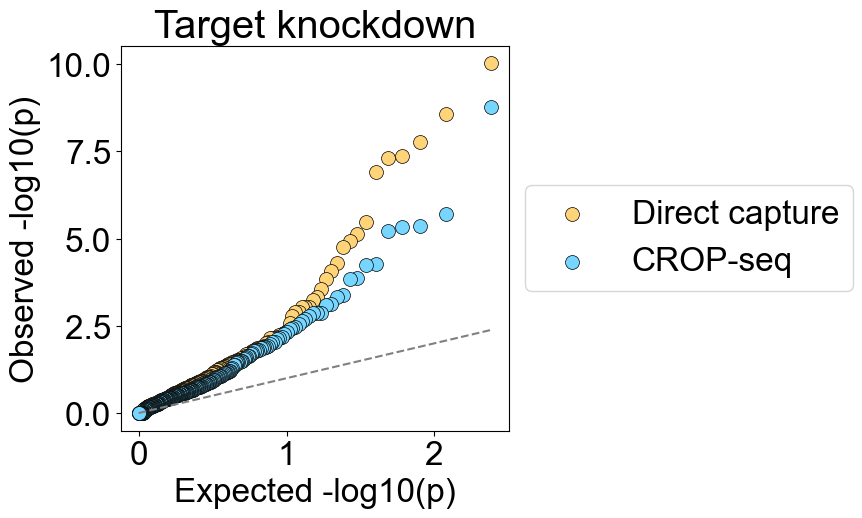

In [90]:
p_values_1 = np.sort(de_direct_crop[de_direct_crop["method"]=="Direct capture"]["pvals"])
p_values_2 = np.sort(de_direct_crop[de_direct_crop["method"]=="CROP-seq"]["pvals"])

# Sort the p-values
sorted_p_values_1 = np.sort(p_values_1)
sorted_p_values_2 = np.sort(p_values_2)

# Calculate the theoretical quantiles (expected under the null hypothesis)
theoretical_quantiles = np.linspace(0, 1, max(len(sorted_p_values_1), len(sorted_p_values_2)))

# Transform to uniform distribution
expected_p_values = -np.log10(theoretical_quantiles[1:])  # Avoid log(0)
observed_p_values_1 = -np.log10(sorted_p_values_1[1:])  # Avoid log(0)
observed_p_values_2 = -np.log10(sorted_p_values_2[1:])  # Avoid log(0)

# Create the QQ plot
plt.scatter(expected_p_values, observed_p_values_1, edgecolor='k', linewidth=0.5, facecolor="#ffd479", label="Direct capture", s=100)
plt.scatter(expected_p_values, observed_p_values_2, edgecolor='k', linewidth=0.5, facecolor="#76d6ff", label="CROP-seq", s=100)
plt.plot([min(expected_p_values), max(expected_p_values)],
         [min(expected_p_values), max(expected_p_values)], color="gray", ls='--')
plt.xlabel('Expected -log10(p)')
plt.ylabel('Observed -log10(p)')
plt.title('Target knockdown')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("knockdown_QQ_plot.png",  dpi=300, bbox_inches="tight")
plt.show()

/var/folders/hz/kz7qqv9d2_d4sjp7b0zyz0y00000gq/T/ipykernel_35437/1081230647.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(y="method", x="logfoldchanges", data=de_direct_crop, join=False)


<Axes: xlabel='logfoldchanges', ylabel='method'>

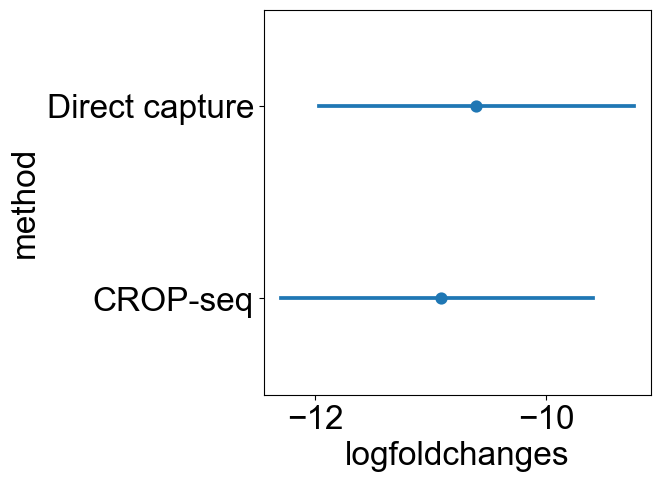

In [98]:
sns.pointplot(y="method", x="logfoldchanges", data=de_direct_crop, join=False)

In [113]:
"TP53" in de_direct_crop["names"].tolist()

True

/var/folders/hz/kz7qqv9d2_d4sjp7b0zyz0y00000gq/T/ipykernel_35437/1751036366.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(y="method", x="ncells", data=de_direct_crop, join=False)


<Axes: xlabel='ncells', ylabel='method'>

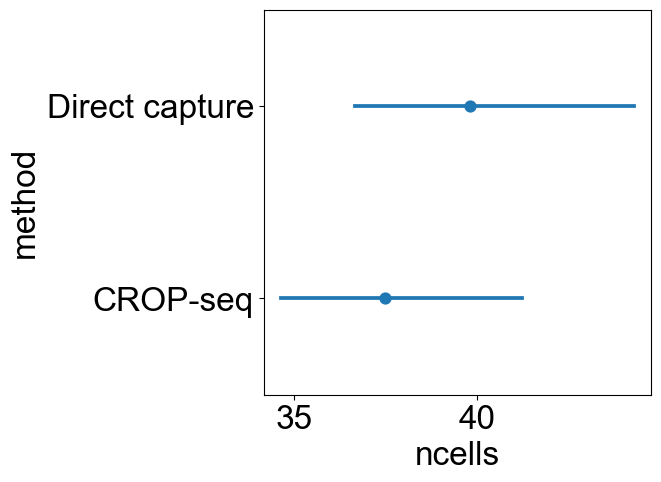

In [100]:
sns.pointplot(y="method", x="ncells", data=de_direct_crop, join=False)

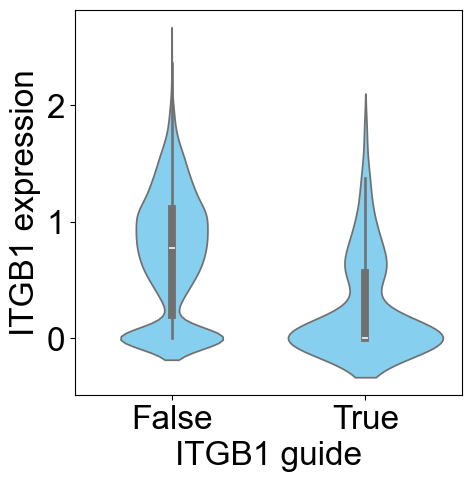

In [160]:
example_crop = gex_crop_copy.obs.merge(gex_crop_copy[:,"ITGB1"].to_df(),
                                    left_index=True, right_index=True, suffixes=["_assign","_expr"])

sns.violinplot(y="ITGB1_expr",
               x="ITGB1_assign",
               data=example_crop,
               color="#76d6ff")
plt.xlabel("ITGB1 guide")
plt.ylabel("ITGB1 expression")
plt.savefig("example.crop.png", dpi=300, bbox_inches="tight")

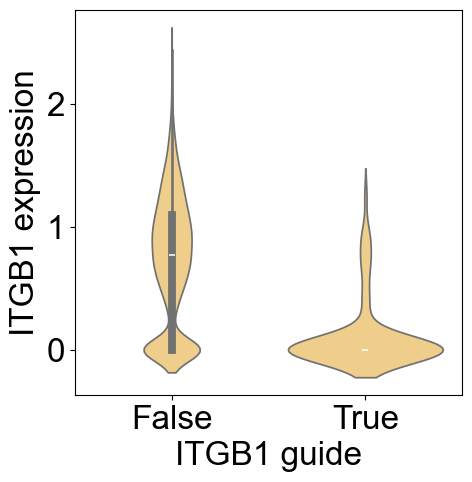

In [161]:
example_dc = gex_copy.obs.merge(gex_copy[:,"ITGB1"].to_df(),
                                left_index=True, right_index=True, suffixes=["_assign","_expr"])

sns.violinplot(y="ITGB1_expr",
               x="ITGB1_assign",
               data=example_dc,
               color="#ffd479")
plt.xlabel("ITGB1 guide")
plt.ylabel("ITGB1 expression")
plt.savefig("example.dc.png", dpi=300, bbox_inches="tight")

<Axes: xlabel='ITGB1_assign', ylabel='ITGB1_expr'>

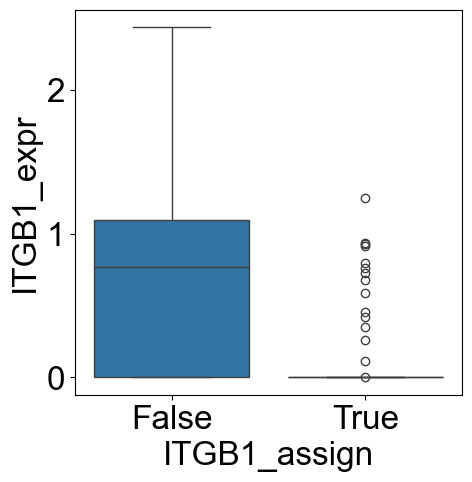

In [124]:
pd.concat([gex_crop_copy.obs,
           gex_crop_copy[:,"TP53"].to_df()], axis=1)

,PDCD7,MEF2A,UBA5,FDPS,SLK,NEK9,INTS10,GADD45A,PRELID1,METTL3,...,FLT1,HMGCL,NSMCE4A,LAMB2,PGF,PECAM1,CDKN1A,YLPM1,targeted,TP53
barcode,,,,,,,,,,,,,,,,,,,,,
AAACATCGAACCGAGATTCCGATC,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.000000
AAACATCGAACTCACCATCCGCGA,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.000000
AAACATCGAAGAGATCGCTCGCGG,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.000000
AAACATCGAAGGACACATCCGCGA,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1.002971
AAACATCGAAGGTACACGCTTAAA,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCACGCATAGGATGATTGGGAGA,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.000000
TTCACGCATCCGTCTAGAGCACAA,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.000000
TTCACGCATCTTCACAGCCGTGTA,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.000000


In [117]:
gex_crop_copy[:,"TP53"]

View of AnnData object with n_obs × n_vars = 6200 × 1
    obs: 'PDCD7', 'MEF2A', 'UBA5', 'FDPS', 'SLK', 'NEK9', 'INTS10', 'GADD45A', 'PRELID1', 'METTL3', 'BCAR1', 'SQLE', 'RHOC', 'C18orf21', 'BMP1', 'C17orf58', 'SNAPC2', 'SWAP70', 'ZAK', 'RHOJ', 'MRPS21', 'NFKBIA', 'DTYMK', 'CDC42EP2', 'JUNB', 'NOS3', 'NFKB1', 'MAPK14', 'SRP72', 'IMPDH2', 'WWTR1', 'PRKAR1A', 'RAB24', 'CCDC85C', 'EGFL7', 'LSS', 'MRPL34', 'RHOG', 'CDC42EP5', 'MORF4L1', 'BRD4', 'C7orf26', 'TLN1', 'MYD88', 'INTS1', 'CAMK2G', 'PES1', 'NUP54', 'SCUBE1', 'TMEM2', 'RABGGTA', 'CCL2', 'TAOK1', 'SVIL', 'non-targeting', 'RBM7', 'MAPK1', 'SGK1', 'PMVK', 'SP1', 'ACAT1', 'CDH5', 'FLI1', 'CDC42EP3', 'SMARCC2', 'RAB5C', 'PALLD', 'CLIC1', 'ARFIP2', 'EIF3E', 'RHOB', 'STAT1', 'MAPK11', 'USP39', 'MVD', 'POLR2D', 'CDC42', 'THBS1', 'MEAF6', 'DNTTIP1', 'RAC2', 'HRAS', 'RNF146', 'RPS6KA4', 'CALCRL', 'SLC4A1AP', 'COL4A1', 'ROCK1', 'IBTK', 'MAP2K3', 'VPS39', 'HMGCS1', 'MAPK3', 'CHD4', 'RHOA', 'CDC42EP1', 'PSMD7', 'PRPF3', 'SOX7', 'MAP3K11', 'FOS

In [171]:
(gex_crop.obs[guides]>=3).sum(axis=1).mean()

2.0375806451612903

<Axes: ylabel='Count'>

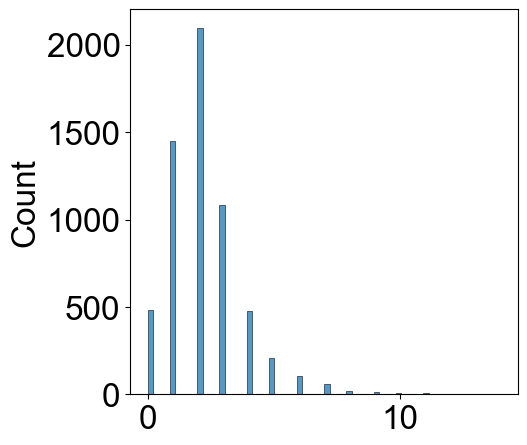

In [179]:
sns.histplot((gex.obs[guides]>=5).sum(axis=1).tolist())

In [178]:
(gex.obs[guides]>=5).sum(axis=1)

barcode
AAACATCGAACCGAGATTCCGATC    0
AAACATCGAACGCTTAATCGCATA    4
AAACATCGAACGCTTAGGTGGAGC    3
AAACATCGAAGAGATCCGCTTAAA    3
AAACATCGAAGGACACTTGGGAGA    2
                           ..
TTCACGCAGTCTGTCAGAGCACAA    0
TTCACGCATATCAGCACGCGACTA    4
TTCACGCATGAAGAGAACGCCGGC    1
TTCACGCATGAAGAGAGTTCAACA    0
TTCACGCATGAAGAGATGTCTGAA    3
Length: 6001, dtype: int64